### 1. 라이브러리들을 임포트

In [102]:
from pathlib import Path
import torch
from torch.utils.data import Subset, DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision import models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

In [103]:
SEED = 2026

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IS_CUDA = DEVICE == "cuda"
NUM_WORKERS = 0 if DEVICE else 0

generator = torch.Generator(device=DEVICE)

np.random.seed(SEED)

### 2. 이미지 데이터 경로 설정 및 클래스 별 개수 확인

In [104]:
IMG_DIR = Path().parent / "data" / "archive" / "The IQ-OTHNCCD lung cancer dataset"

print(IMG_DIR.resolve().exists())

True


In [105]:
data = ImageFolder(IMG_DIR)
len(data), data.class_to_idx

(1097, {'Bengin cases': 0, 'Malignant cases': 1, 'Normal cases': 2})

In [106]:
idx_to_class = {
  idx: class_
  for class_, idx
  in data.class_to_idx.items()
}

print("classed:", idx_to_class)

count = dict()

for _, label in data.samples:
  try:
    count[label] += 1
  except:
    count[label] = 1

print("count:", {
  idx_to_class[idx]: count
  for idx, count
  in count.items()
})

classed: {0: 'Bengin cases', 1: 'Malignant cases', 2: 'Normal cases'}
count: {'Bengin cases': 120, 'Malignant cases': 561, 'Normal cases': 416}


### 3. 모델 학습을 위해 이미지 데이터를 전처리하세요.

In [107]:
transform = {
  "train": transforms.Compose([
    transforms.RandomResizedCrop(224, (0.9, 1.0)),
    transforms.RandomAffine(
      degrees=10,
      translate=(0.05, 0.05),
      scale=(0.9, 1.1),
      shear=5
    ),
    transforms.ToTensor(),
    # transforms.Normalize(mean=, std=)
  ]),
  "val": transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
    # transforms.Normalize(mean=, std=)
  ])
}

In [108]:
all_indices = np.arange(len(data))
all_targets = np.array(data.targets)

train_indices, val_indices = train_test_split(
  all_indices,
  test_size=0.2,
  random_state=SEED,
  stratify=all_targets
)

In [109]:
train_datasets = ImageFolder(
  IMG_DIR,
  transform=transform["train"]
)

train_datasets = Subset(
  train_datasets,
  train_indices
)

val_datasets = ImageFolder(
  IMG_DIR,
  transform=transform["val"]
)

val_datasets = Subset(
  val_datasets,
  val_indices
)

In [110]:
train_loader = DataLoader(
  train_datasets,
  batch_size=32,
  shuffle=True,
)

val_loader = DataLoader(
  val_datasets,
  batch_size=32,
  shuffle=False
)

### 4. YOLO가 아닌 이미지 분류 모델을 선택하여 사용하세요.

In [111]:
model = models.densenet121(
  weights=models.DenseNet121_Weights.DEFAULT
)

### 5. 선택한 모델을 폐암 분류 문제에 맞게 수정하세요.

In [112]:
in_features = model.classifier.in_features
in_features

1024

In [113]:
model.classifier = torch.nn.Linear(
  in_features,
  3
)

model.to(DEVICE)

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, bias=T

### 6. 손실 함수, 옵티마이저, 평가 지표를 설정하세요. (수업시간에 배운 내용을 토대로 손실 함수, 옵티마이저, 평가 지표를 설정하세요)

In [114]:
criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
  model.parameters(),
  lr=1e-4,
  weight_decay=0.01
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
  optimizer,
  mode="min",
  patience=3,
  factor=0.5
)

In [115]:
def train_one_epoch(data_loader, model, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_correct=0
    total_samples=0

    for images, labels in data_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == labels).sum().item()

        total_samples += batch_size

    average_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    return average_loss, accuracy

In [116]:
def evaluate(data_loader, model, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.inference_mode():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)

            batch_size = labels.size(0)

            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_samples += batch_size

    average_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    return average_loss, accuracy

### 7. 전처리된 학습 데이터를 사용하여 모델을 학습하세요.

In [117]:
EPOCHS=3

for epoch in range(1, EPOCHS+1):
    train_loss, train_accuracy = train_one_epoch(train_loader, model, criterion, optimizer, DEVICE)

    validation_loss, validation_accuracy = evaluate(val_loader, model, criterion, DEVICE)

    scheduler.step(validation_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    print(f'Epoch [{epoch:02d}/{EPOCHS}]'
        f'lr={current_lr:.6f} | '
        f'train loss={train_loss:.4f}, acc={train_accuracy:.4f} | '
        f'val loss={validation_loss:.4f}, acc={validation_accuracy:.4f}'
    )

Epoch [01/3]lr=0.000100 | train loss=0.4786, acc=0.8119 | val loss=0.4821, acc=0.7727
Epoch [02/3]lr=0.000100 | train loss=0.2335, acc=0.8985 | val loss=0.2603, acc=0.9000
Epoch [03/3]lr=0.000100 | train loss=0.1275, acc=0.9635 | val loss=0.3006, acc=0.8682


### 8. 검증 데이터에 대한 성능을 평가하고 결과를 출력하세요. (수업시간에 배운 평가 지표를 토대로 결과를 출력하고 데이터에 대한 인사이트를 기술하세요)

In [118]:
y_true = []
y_pred = []

model.eval()

with torch.inference_mode():
  for images, labels in val_loader:
    images = images.to(DEVICE)

    logits = model(images)
    preds = logits.argmax(dim=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds.cpu().numpy())

Accuracy: 0.8681818181818182
                 precision    recall  f1-score   support

   Bengin cases       0.45      1.00      0.62        24
Malignant cases       1.00      1.00      1.00       113
   Normal cases       1.00      0.65      0.79        83

       accuracy                           0.87       220
      macro avg       0.82      0.88      0.80       220
   weighted avg       0.94      0.87      0.88       220



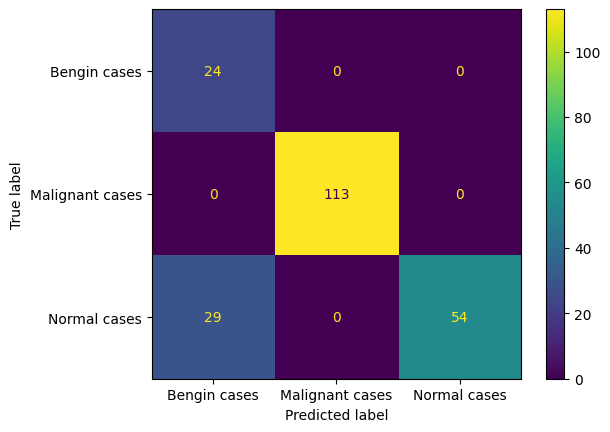

In [119]:
print("Accuracy:", accuracy_score(y_true, y_pred))

print(
    classification_report(
        y_true,
        y_pred,
        target_names=data.classes
    )
)

cm = confusion_matrix(y_true, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.classes
).plot()

결과는 아래와 같이 나왔습니다.

```
Accuracy: 0.8681818181818182
                 precision    recall  f1-score   support

   Bengin cases       0.45      1.00      0.62        24
Malignant cases       1.00      1.00      1.00       113
   Normal cases       1.00      0.65      0.79        83

       accuracy                           0.87       220
      macro avg       0.82      0.88      0.80       220
   weighted avg       0.94      0.87      0.88       220
```

정확도는 꽤 높게 나왔으며 이는 DenseNet가 이미 잘 학습된 모델이여서로 생각할 수 있습니다. (이미지 데이터가 많지 않았기 때문에)

또한 평가 지표로는 암과 같은 치명적이고 현재와 같이 데이터가 적은 데이터에서는 weighted avg를 보는것이 맞다고 생각하였으며 그렇게 판단을 하였을 때
- `precision 0.94`: 악성 평가시에 정상을 악성으로 잡은 확률이 있지만 악성을 정상으로 평가하는 것보다는 나은 결과입니다. (Bengin에서 정확도가 0.45입니다.)
- `recall 0.87`: 해당 부분이 더욱 중요한 부분으로 놓침없이 예측을 잘 해냈는지를 판단할 때, `악성 - Malignant`과 `양성 - Bengin` 모두 `1.00`이라는 수치를 기록했기 때문에 현재 상황은 나쁘지 않다고 생각했습니다.
- `f1-score 0.88`: 전체적인 비율에서 악성은 매우 좋으나 데이터가 적을수록 조화평균 값이 줄어드는 것을 알수 있습니다.

> 최종적으로 데이터가 24밖에 없는 Bengin이 추측이 잘 된것은 우연일 수 있다는 생각이 들며 만약 실제로 개발을 하는 입장이라면 더욱 많은 데이터를 수집할 것 같습니다.

### 9. 임의의 이미지 6장을 선택하여 예측을 수행하고 해당 결과를 해석하세요.

In [131]:
# 랜덤 값 뽑기
rand_indices = np.random.choice(len(val_datasets), size=6, replace=False)

print(rand_indices)

targets = []
pred = []

model.eval()

for idx in rand_indices:
  x, y = val_datasets[idx]
  targets.append(y)

  x = x.to(DEVICE)
  with torch.inference_mode():
    pred.append(model(x.unsqueeze(0)).argmax(dim=1).item())

model.train()

print(targets)
print(pred)

[198  66 177 102  76  45]
[2, 1, 2, 2, 2, 0]
[0, 1, 0, 2, 2, 0]


C:\Users\hurwa\AppData\Local\Temp\ipykernel_32340\3561705252.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


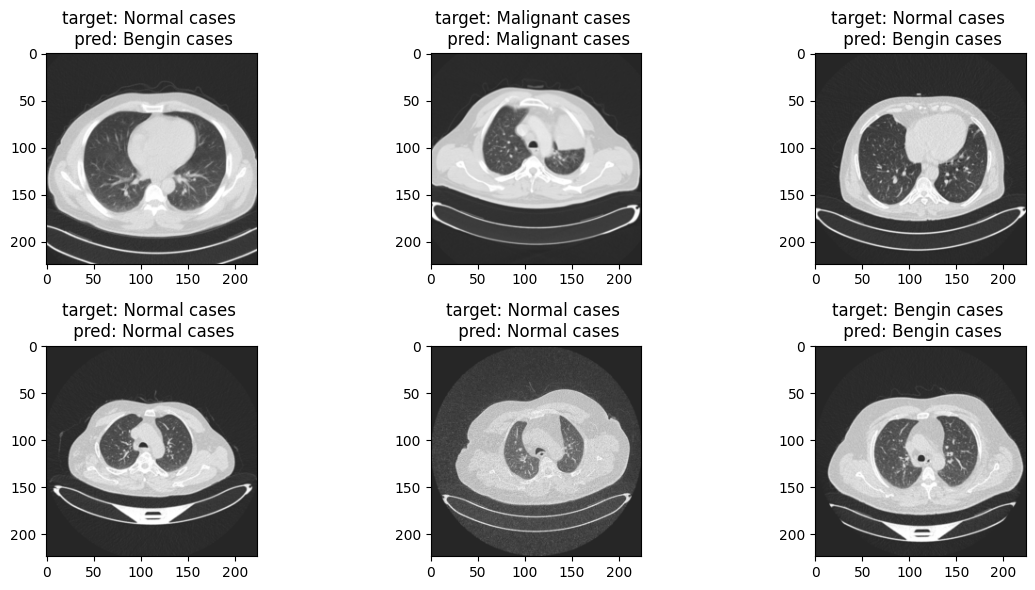

In [132]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for num, (idx, ax) in enumerate(zip(rand_indices, axes.flatten())):
  x = val_datasets[idx][0]
  x = x.permute(1, 2, 0)
  ax.imshow(x)
  ax.set_title(f"target: {idx_to_class[targets[num]]} \n pred: {idx_to_class[pred[num]]}")

fig.tight_layout()
fig.show()

### 결과 해석
이번에도 역시 위에서 서술하였듯, 정상을 양성으로 판단하는 경우 이외에는 별 문제가 없음을 알 수 있습니다.

하지만 해당 결과가 나오기 전 테스트를 한번 더 돌렸을 때 (모델을 초기화 하기 전) Bengin recall이 0.29였으며 실제로 6개중 정상과 악성은 모두 맞추었지만 1개만 존재하는 Bengin은 Normal로 판단하였던 문제가 있었습니다.

이에 따라 아직은 결과를 판단하기 이르다고 말할 수 있을 것 같습니다.

### 10. 의료 영상 기반 폐암 분류 모델을 실제 의료 현장에 적용할 때 고려해야 할 윤리적·기술적 문제점 2가지를 서술하세요.

> 해당 내용은 첫번째 모델 사용을 기준으로 작성한 내용입니다. 첫번째 모델의 검증 결과는 아래와 같았습니다.

```
                 precision   recall
Benign              0.78      0.29
Malignant           1.00      0.99
Normal              0.82      0.98
```

윤리적 문제에서는 위에(8번 문항)서 서술하였듯, 암과 같은 치명적인 질병에서는 precision은 좋으면 좋겠지만 더욱 중요한 것은 recall이라는 얼마나 빠짐없이 양성값을 발견하였냐 에 대한 내용입니다.

이러한 이야기는 윤리적 문제중 하나의 대표적인 예시일 뿐이며 의료 관련 사람에게 직접적인 영향을 끼칠 수 있는 문제에서 더욱 깐깐하게 다가가야하며 전문가(보통 의사)의 감독 하에 사용이 되어야합니다.

또한 개발진에서도 이에 대한 사실을 명확히 인지하며 그 책임을 가지고 제작에 임할 필요가 있습니다.

---

기술적인 문제의 경우에는 모델을 만들며 평가할 때, 편향이 일어나지 않게 주의해야할 필요가 있습니다.

예를 들어 이번 데이터셋의 모습은 다음과 같습니다.

```
양성 - Bengin: 24
악성 - Malignant: 113
정상 - Normal: 83
```

여기에서 양성은 매우 적고, 정상과 양성(양성 + 악성)의 비율중 양성의 비중이 조금 더 높습니다.

이러한 비율 문제는 데이터가 많아짐에 따라 점점 줄어들겠지만 데이터가 한쪽에 쏠려있음에 따라 모델의 성능이 달라지는 것은 주의해야할 요소입니다.

또한 위의 경우에는 이미지 데이터이기 떄문에 동일한 환경에서 만들어진 이미지인지까지 명확히 하면 더욱 좋은 결과가 생길 수 있습니다